# 1. Import Data dari Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
path = '/content/drive/MyDrive/FILE SETELAH LULUS/Dataset/product_review_sentiment_dataset (1).csv'
df = pd.read_csv(path)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   review_id          64 non-null     object
 1   product_category   64 non-null     object
 2   product_name       64 non-null     object
 3   rating             64 non-null     int64 
 4   review_text        64 non-null     object
 5   sentiment          64 non-null     object
 6   review_length      64 non-null     object
 7   verified_purchase  64 non-null     object
 8   contains_sarcasm   64 non-null     bool  
 9   mixed_sentiment    64 non-null     bool  
 10  review_date        64 non-null     object
dtypes: bool(2), int64(1), object(8)
memory usage: 4.8+ KB



## Interpretasi Struktur Dataset

Pemeriksaan awal menunjukkan bahwa dataset berhasil dimuat dengan baik dan memiliki struktur yang sesuai untuk analisis NLP.

Dataset terdiri dari **64 review pelanggan** dengan beberapa atribut pendukung. Kolom teks review menjadi sumber utama informasi karena mengandung opini, pengalaman penggunaan, serta keluhan pelanggan.

Pada tahap ini, fokus utama adalah memastikan:
- data dapat digunakan untuk pemrosesan teks,
- tidak terdapat masalah struktural,
- atribut yang relevan dapat dipilih untuk analisis berikutnya.

Dataset yang relatif kecil membuat strategi pemodelan perlu mempertimbangkan risiko overfitting dan pentingnya interpretasi hasil model.


Berdasarkan hasil pemeriksaan struktur dataset, dataset terdiri dari 64 review pelanggan dengan 11 atribut pendukung.

Kolom review_text memiliki tipe data object yang menunjukkan bahwa variabel tersebut merupakan data teks tidak terstruktur yang akan digunakan sebagai sumber utama analisis Natural Language Processing (NLP).

Kolom sentiment juga memiliki tipe data object yang menunjukkan bahwa variabel tersebut merupakan label kategorikal yang akan digunakan sebagai target pada proses sentiment classification.

Selain teks review dan label sentimen, dataset menyediakan informasi tambahan seperti rating produk, kategori produk, status pembelian terverifikasi, serta indikator adanya sarcasm dan mixed sentiment. Informasi tambahan tersebut dapat digunakan untuk analisis lanjutan dalam memahami faktor yang memengaruhi persepsi pelanggan.

Dari sisi kualitas struktur data, seluruh variabel memiliki jumlah observasi yang sama, yaitu 64 baris, sehingga tidak terdapat indikasi kehilangan data pada tahap awal eksplorasi.

# 2. Ekplorasi Data

In [7]:
# memeriksa missing values

missing = df.isnull().sum()

missing

,0
review_id,0
product_category,0
product_name,0
rating,0
review_text,0
sentiment,0
review_length,0
verified_purchase,0
contains_sarcasm,0
mixed_sentiment,0



## Interpretasi Missing Value

Hasil pemeriksaan menunjukkan bahwa seluruh kolom tidak memiliki nilai kosong.

Hal ini menunjukkan bahwa:
- tidak diperlukan imputasi data,
- seluruh observasi dapat dipertahankan,
- proses preprocessing teks dapat dilakukan tanpa kehilangan informasi.

Kondisi data yang lengkap mendukung konsistensi pada tahap analisis sentimen dan topic modeling.


Hasil pemeriksaan missing value menunjukkan bahwa seluruh variabel dalam dataset memiliki nilai lengkap untuk seluruh observasi.

Tidak ditemukan data kosong pada variabel utama seperti:

review_text
sentiment
rating

Hal ini menunjukkan bahwa dataset tidak membutuhkan proses imputasi atau penghapusan observasi akibat missing value.

Kondisi ini penting dalam pipeline NLP karena kolom teks yang kosong dapat menyebabkan error pada proses preprocessing seperti:

tokenization
stopword removal
feature extraction

Dengan tidak adanya missing value, seluruh 64 review dapat langsung digunakan pada tahap text preprocessing.

In [8]:
# pemeriksaan data duplikat
duplicates = df.duplicated().sum()

print(
    f"Jumlah data duplicate: {duplicates}"
)

Jumlah data duplicate: 0



## Interpretasi Data Duplikat

Tidak ditemukan observasi duplikat pada dataset.

Artinya setiap review dianggap sebagai informasi pelanggan yang berbeda sehingga tidak terdapat risiko satu opini pelanggan mendominasi hasil analisis akibat pengulangan data.

Namun, pemeriksaan duplikasi berbasis teks tetap perlu diperhatikan karena review yang memiliki makna serupa dapat tetap muncul meskipun tidak identik secara karakter.


Berdasarkan pemeriksaan duplikasi, tidak ditemukan observasi yang memiliki kombinasi nilai identik pada seluruh variabel.

Tidak adanya data duplikat menunjukkan bahwa setiap review dianggap sebagai observasi yang berbeda.

Hal ini mengurangi risiko bias pada tahap modeling karena model tidak akan menerima contoh teks yang sama secara berulang.

Dalam konteks sentiment analysis, data duplikat dapat menyebabkan:

performa model terlihat lebih tinggi dari kondisi sebenarnya,
model terlalu menghafal pola tertentu,
evaluasi menjadi kurang representatif.

Karena tidak terdapat duplikasi, dataset dapat digunakan langsung untuk proses analisis berikutnya.

In [9]:
# statistika deskriptif

df.describe()

,rating
count,64.000000
mean,3.203125
std,1.404976
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


Statistik deskriptif menunjukkan bahwa variabel numerik pada dataset hanya terdiri dari variabel rating.

Jumlah observasi rating adalah 64, sesuai dengan jumlah total review.

Nilai rata-rata rating pelanggan adalah:

$$ \bar{x}=3.20 $$

yang menunjukkan bahwa secara umum pelanggan memberikan penilaian pada tingkat moderat.

Nilai median sebesar 3 menunjukkan bahwa separuh pelanggan memberikan rating di bawah atau sama dengan 3, sedangkan separuh lainnya memberikan rating di atas atau sama dengan 3.

Rentang rating berada antara 1 hingga 5, sesuai dengan skala evaluasi produk.

Nilai standar deviasi sebesar 1.40 menunjukkan adanya variasi penilaian pelanggan yang cukup besar. Artinya, pengalaman pelanggan tidak sepenuhnya homogen, karena terdapat pelanggan yang memberikan rating sangat rendah maupun sangat tinggi.

Variasi rating ini menjadi indikasi awal bahwa dataset memiliki perbedaan opini pelanggan yang relevan untuk dilakukan analisis sentimen.

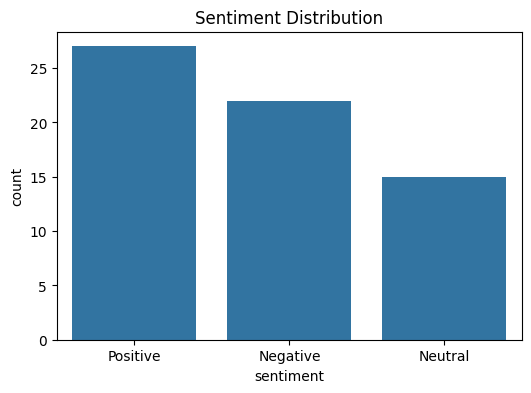

In [10]:
# Distribusi Sentimen
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title(
    "Sentiment Distribution"
)

plt.show()


## Interpretasi Distribusi Sentimen

Distribusi kelas menunjukkan bahwa opini pelanggan relatif tersebar pada tiga kategori sentimen.

Kondisi ini memberikan keuntungan karena model klasifikasi tidak menghadapi ketidakseimbangan kelas yang ekstrem.

Meskipun demikian, jumlah data yang kecil tetap menjadi tantangan karena setiap kesalahan prediksi memiliki pengaruh besar terhadap metrik evaluasi.


Distribusi sentimen menunjukkan bahwa kategori positif merupakan kelas dengan jumlah observasi terbesar sebanyak 27 review, diikuti oleh sentimen negatif sebanyak 22 review dan sentimen netral sebanyak 15 review.

Meskipun kelas positif memiliki jumlah observasi lebih tinggi, perbedaannya tidak terlalu besar dibandingkan kelas lainnya.

Proporsi kelas:

Sentiment	Proporsi
Positive	42.2%
Negative	34.4%
Neutral	23.4%

Distribusi tersebut menunjukkan bahwa dataset relatif cukup seimbang.

Kondisi ini menguntungkan untuk proses supervised learning karena model tidak mengalami dominasi kelas tertentu yang ekstrem.

Namun, karena jumlah dataset hanya 64 observasi, evaluasi model tidak cukup hanya menggunakan accuracy. Evaluasi perlu mempertimbangkan:

precision
recall
F1-score
confusion matrix

untuk melihat kemampuan model mengenali setiap kelas sentimen.

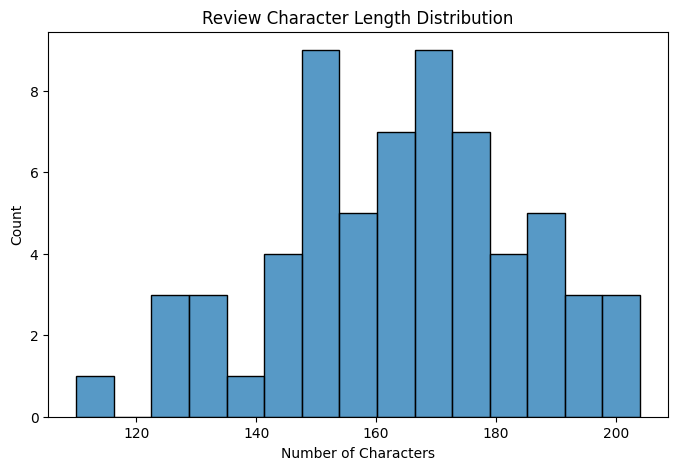

In [11]:
# distribusi panjang review
df["char_length"] = (
    df["review_text"]
    .astype(str)
    .str.len()
)


df["char_length"].describe()

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="char_length",
    bins=15
)

plt.title(
    "Review Character Length Distribution"
)

plt.xlabel(
    "Number of Characters"
)

plt.show()

Analisis panjang teks menunjukkan bahwa review pelanggan memiliki panjang yang relatif konsisten.

Rata-rata panjang review adalah sekitar 164 karakter dengan variasi sekitar 20 karakter.

Nilai minimum sebesar 110 karakter menunjukkan bahwa seluruh review memiliki informasi tekstual yang cukup untuk dilakukan analisis NLP.

Sementara itu, nilai maksimum sebesar 204 karakter menunjukkan bahwa tidak terdapat review yang sangat panjang sehingga membutuhkan strategi khusus seperti truncation.

Distribusi panjang teks yang relatif homogen memberikan keuntungan pada tahap preprocessing dan feature extraction karena:

setiap dokumen memiliki jumlah informasi yang relatif seimbang,
TF-IDF dapat bekerja dengan baik,
computational cost pada tahap modeling tetap rendah.

Karakteristik ini sesuai dengan pendekatan machine learning berbasis teks seperti:

TF-IDF + Logistic Regression
TF-IDF + Support Vector Machine
Naive Bayes

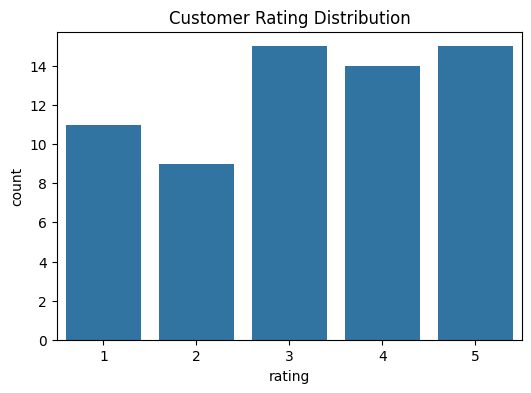

In [12]:
# distribusi rating
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="rating"
)

plt.title(
    "Customer Rating Distribution"
)

plt.show()

Distribusi rating menunjukkan bahwa seluruh kategori rating dari 1 hingga 5 terdapat dalam dataset.

Rating 3 dan 5 memiliki jumlah observasi terbesar masing-masing sebanyak 15 review, sedangkan rating 2 memiliki jumlah paling sedikit sebanyak 9 review.

Distribusi ini menunjukkan bahwa opini pelanggan cukup beragam, mulai dari pengalaman yang sangat negatif hingga sangat positif.

Menariknya, rating tidak hanya dapat digunakan sebagai variabel deskriptif, tetapi juga dapat dibandingkan dengan label sentimen.

Perbandingan antara rating dan sentiment diperlukan karena:

rating rendah umumnya berkorelasi dengan sentimen negatif,
rating tinggi umumnya berkorelasi dengan sentimen positif,
tetapi beberapa kasus dapat menunjukkan ketidaksesuaian akibat sarcasm atau mixed sentiment.

Analisis hubungan rating dan sentiment dapat membantu mengidentifikasi inkonsistensi label serta memahami kompleksitas opini pelanggan.

# 3. Analisis Sentimen


## Interpretasi Strategi Analisis Sentimen

Analisis sentimen dilakukan menggunakan tiga pendekatan dengan tingkat kompleksitas berbeda:

1. Lexicon-based approach untuk baseline tanpa pelatihan model.
2. Traditional machine learning menggunakan representasi TF-IDF.
3. Transformer-based approach menggunakan representasi berbasis konteks.

Perbandingan ini bertujuan mengevaluasi bagaimana representasi teks memengaruhi kemampuan model memahami opini pelanggan.


| Tahap Analisis | Pendekatan                       | Representasi Teks       | Algoritma / Model                   | Tujuan Analisis                                                                                 |
| -------------- | -------------------------------- | ----------------------- | ----------------------------------- | ----------------------------------------------------------------------------------------------- |
| Baseline 1     | Lexicon-Based Sentiment Analysis | Sentiment Lexicon       | VADER Sentiment Analyzer            | Mengukur performa pendekatan berbasis aturan tanpa proses training model                        |
| Baseline 2     | Traditional Machine Learning     | TF-IDF Vectorization    | Multinomial Naive Bayes             | Menjadi baseline klasik NLP berbasis probabilistic learning                                     |
| Model 1        | Traditional Machine Learning     | TF-IDF Vectorization    | Logistic Regression                 | Membangun model klasifikasi sentimen yang sederhana, stabil, dan mudah diinterpretasikan        |
| Model 2        | Traditional Machine Learning     | TF-IDF Vectorization    | Linear Support Vector Machine (SVM) | Mengevaluasi performa model yang kuat untuk klasifikasi teks berdimensi tinggi                  |
| Model 3        | Transformer-Based Approach       | Sentence-BERT Embedding | Logistic Regression                 | Menguji pengaruh contextual text representation dibandingkan pendekatan berbasis frekuensi kata |


## Lexicon-Based

Preprocessing yang dilakukan

| Proses               | Status      |
| -------------------- | ----------- |
| Remove HTML          | Ya          |
| Remove URL           | Ya          |
| Normalize whitespace | Ya          |
| Lowercase            | Tidak wajib |
| Remove punctuation   | Tidak       |
| Remove emoji         | Tidak       |
| Stopword removal     | Tidak       |


### 1. Import Library

In [13]:
import pandas as pd
import numpy as np

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [15]:
df.head()

,review_id,product_category,product_name,rating,review_text,sentiment,review_length,verified_purchase,contains_sarcasm,mixed_sentiment,review_date,char_length
0,REV0001,Electronics,Wireless Earbuds Pro,5,These earbuds are incredible. Sound quality is...,Positive,medium,Yes,False,False,2024-09-10,153
1,REV0002,Electronics,Smart Home Hub,5,Finally got the whole ecosystem working. Setup...,Positive,short,Yes,False,False,2024-09-08,128
2,REV0003,Clothing,Running Shoes,5,Wearing these for my morning runs and they're ...,Positive,short,Yes,False,False,2024-09-12,157
3,REV0004,Home & Garden,Cordless Drill,4,This drill does everything I need and more. Po...,Positive,medium,Yes,False,False,2024-09-05,178
4,REV0005,Beauty,Anti-Wrinkle Serum,5,"Wow, I've seen real results in just 3 weeks. M...",Positive,short,Yes,False,False,2024-09-11,156


### 2. Preprocessing teks minimalist Vader

| Proses               | Status | Alasan                                     |
| -------------------- | ------ | ------------------------------------------ |
| Remove HTML          | ✅      | Menghilangkan noise format                 |
| Remove URL           | ✅      | URL tidak relevan terhadap polaritas       |
| Normalize whitespace | ✅      | Menjaga konsistensi teks                   |
| Lowercase            | ❌      | Kapitalisasi memiliki informasi intensitas |
| Remove punctuation   | ❌      | Punctuation membawa sinyal emosi           |
| Remove emoji         | ❌      | Emoji mengandung informasi sentimen        |
| Stopword removal     | ❌      | Negasi dapat mengubah polaritas            |


In [18]:
import re

def preprocess_vader(text):
    """
    Minimal preprocessing for VADER.
    Preserve sentiment-related features such as:
    - punctuation
    - capitalization
    - emoji
    """

    text = str(text)

    # Remove HTML tags
    text = re.sub(
        r'<.*?>',
        ' ',
        text
    )

    # Remove URLs
    text = re.sub(
        r'http\S+|www\S+',
        ' ',
        text
    )

    # Normalize whitespace
    text = " ".join(
        text.split()
    )

    return text

In [20]:
df["vader_text"] = df["review_text"].apply(
    preprocess_vader
)

df[
    [
        "review_text",
        "vader_text"
    ]
].head()

,review_text,vader_text
0,These earbuds are incredible. Sound quality is...,These earbuds are incredible. Sound quality is...
1,Finally got the whole ecosystem working. Setup...,Finally got the whole ecosystem working. Setup...
2,Wearing these for my morning runs and they're ...,Wearing these for my morning runs and they're ...
3,This drill does everything I need and more. Po...,This drill does everything I need and more. Po...
4,"Wow, I've seen real results in just 3 weeks. M...","Wow, I've seen real results in just 3 weeks. M..."


### 3. Skoring Vader

VADER (Valence Aware Dictionary and sEntiment Reasoner) bekerja dengan prinsip:

Menghitung kekuatan sentimen dalam sebuah teks berdasarkan kamus kata sentimen dan aturan linguistik.

Jadi VADER tidak belajar dari dataset kamu.

In [21]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()


df["vader_score"] = df["vader_text"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

df[
    [
        "review_text",
        "vader_score"
    ]
].head()

,review_text,vader_score
0,These earbuds are incredible. Sound quality is...,0.2942
1,Finally got the whole ecosystem working. Setup...,0.9098
2,Wearing these for my morning runs and they're ...,0.8588
3,This drill does everything I need and more. Po...,0.8991
4,"Wow, I've seen real results in just 3 weeks. M...",0.7755


In [22]:
def vader_label(score):
    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

In [23]:
df["vader_prediction"] = df["vader_score"].apply(
    vader_label
)

In [24]:
df[
    [
        "review_text",
        "vader_score",
        "vader_prediction"
    ]
].head()

,review_text,vader_score,vader_prediction
0,These earbuds are incredible. Sound quality is...,0.2942,Positive
1,Finally got the whole ecosystem working. Setup...,0.9098,Positive
2,Wearing these for my morning runs and they're ...,0.8588,Positive
3,This drill does everything I need and more. Po...,0.8991,Positive
4,"Wow, I've seen real results in just 3 weeks. M...",0.7755,Positive


### 4. Cek ground truth

In [25]:
comparison = df[
    [
        "review_text",
        "sentiment",
        "vader_score",
        "vader_prediction"
    ]
]


comparison.head(10)

,review_text,sentiment,vader_score,vader_prediction
0,These earbuds are incredible. Sound quality is...,Positive,0.2942,Positive
1,Finally got the whole ecosystem working. Setup...,Positive,0.9098,Positive
2,Wearing these for my morning runs and they're ...,Positive,0.8588,Positive
3,This drill does everything I need and more. Po...,Positive,0.8991,Positive
4,"Wow, I've seen real results in just 3 weeks. M...",Positive,0.7755,Positive
5,Page-turner! Couldn't put it down. The plot tw...,Positive,0.3382,Positive
6,Makes excellent coffee every single time. The ...,Positive,0.7351,Positive
7,"Perfect thickness, doesn't slip during workout...",Positive,0.7964,Positive
8,Spent $400 on this chair and haven't regretted...,Positive,0.6988,Positive
9,My pup absolutely loves this bed. She sleeps t...,Positive,0.9223,Positive


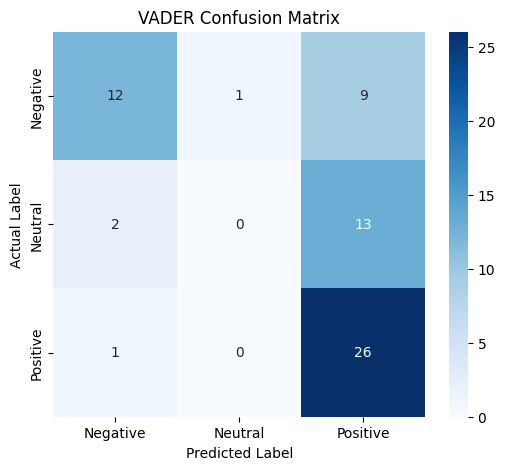

In [26]:
labels = [
    "Negative",
    "Neutral",
    "Positive"
]


cm = confusion_matrix(
    df["sentiment"],
    df["vader_prediction"],
    labels=labels
)


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.title(
    "VADER Confusion Matrix"
)

plt.show()

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


y_true = df["sentiment"]
y_pred = df["vader_prediction"]


accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

vader_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})


vader_metrics["Score"] = (
    vader_metrics["Score"]
    .round(4)
)


vader_metrics

,Metric,Score
0,Accuracy,0.5938
1,Precision,0.5035
2,Recall,0.5938
3,F1-Score,0.5155


### 5. error analysis


## Interpretasi Error Analysis VADER

Kesalahan klasifikasi pada pendekatan lexicon menunjukkan bahwa model berbasis kamus memiliki keterbatasan dalam memahami konteks.

Beberapa review negatif dapat mengandung kata positif atau struktur kalimat kompleks sehingga skor sentimen tidak selalu sesuai dengan persepsi manusia.

Hal ini menunjukkan pentingnya pendekatan berbasis machine learning dan transformer untuk menangkap hubungan antar kata dalam konteks kalimat.


In [28]:
error_analysis = df[
    df["sentiment"] != df["vader_prediction"]
]


error_analysis[
    [
        "review_text",
        "sentiment",
        "vader_prediction",
        "vader_score"
    ]
]

,review_text,sentiment,vader_prediction,vader_score
16,Half the recipes have typos in the ingredients...,Negative,Positive,0.1280
17,Bands snapped after 10 uses. Clearly cheap mat...,Negative,Neutral,-0.0003
18,Cat refuses to use it. Design is awkward and h...,Negative,Positive,0.3581
19,Size S should fit medium but these fit like to...,Negative,Positive,0.4767
20,It's a phone case. Does what it's supposed to ...,Neutral,Positive,0.4023
21,Regular garden hose. Works fine for watering p...,Neutral,Positive,0.1027
22,Spatula works fine. Non-stick surface hasn't c...,Neutral,Positive,0.7355
23,Had to buy this for my class. Content is clear...,Neutral,Positive,0.6705
24,"Bookshelf holds books. Constructed fine, looks...",Neutral,Positive,0.4019
25,"Processor is great and fast, but the keyboard ...",Neutral,Negative,-0.7839


## Traditional Machine Learning

Model:


*   Logistic Regression
*   Linear SVM
*   Multinomial Naive Bayes


Preprocessing yang dilakukan

| Proses             | Status                      |
| ------------------ | --------------------------- |
| Lowercase          | Ya                          |
| Remove punctuation | Ya                          |
| Tokenization       | Ya                          |
| Stopword removal   | Ya dengan negation handling |
| Lemmatization      | Ya                          |


### 1. Preprocessing

In [29]:
import re
import nltk
import pandas as pd
import numpy as np

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [30]:
# membuat stopword dengan negasi handling
stopwords.words("english")

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [31]:
stop_words = set(
    stopwords.words("english")
)


negation_words = {
    "not",
    "no",
    "nor",
    "never"
}


stop_words = stop_words - negation_words

In [32]:
# lemmatisasi
lemmatizer = WordNetLemmatizer()

In [33]:
def preprocess_ml(text):

    # memastikan tipe data string
    text = str(text)


    # lowercase
    text = text.lower()


    # remove HTML tag
    text = re.sub(
        r"<.*?>",
        " ",
        text
    )


    # remove URL
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )


    # remove punctuation
    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )


    # normalize whitespace
    text = " ".join(
        text.split()
    )


    # tokenization
    tokens = text.split()


    # stopword removal + lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]


    return " ".join(tokens)

In [34]:
df["clean_text"] = df["review_text"].apply(
    preprocess_ml
)

In [36]:
df[
    [
        "review_text",
        "clean_text"
    ]
].head(10)

,review_text,clean_text
0,These earbuds are incredible. Sound quality is...,earbuds incredible sound quality crisp bass de...
1,Finally got the whole ecosystem working. Setup...,finally got whole ecosystem working setup easy...
2,Wearing these for my morning runs and they're ...,wearing morning run fantastic comfy start no b...
3,This drill does everything I need and more. Po...,drill everything need powerful feel good hand ...
4,"Wow, I've seen real results in just 3 weeks. M...",wow seen real result week skin look firmer glo...
5,Page-turner! Couldn't put it down. The plot tw...,page turner put plot twist genuinely surprisin...
6,Makes excellent coffee every single time. The ...,make excellent coffee every single time progra...
7,"Perfect thickness, doesn't slip during workout...",perfect thickness slip workout roll tight colo...
8,Spent $400 on this chair and haven't regretted...,spent chair regretted second sit hour day work...
9,My pup absolutely loves this bed. She sleeps t...,pup absolutely love bed sleep night without re...


### 2. Train test Split

In [37]:
X = df["clean_text"]
y = df["sentiment"]

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
# cek distribusi setelah di split
stratify=y

print("Training Distribution")
print(y_train.value_counts(normalize=True))


print("\nTesting Distribution")
print(y_test.value_counts(normalize=True))

Training Distribution
sentiment
Positive    0.411765
Negative    0.352941
Neutral     0.235294
Name: proportion, dtype: float64

Testing Distribution
sentiment
Positive    0.461538
Negative    0.307692
Neutral     0.230769
Name: proportion, dtype: float64


### TF IDF

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1,2),
    min_df=1
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Shape of X_train_tfidf: (51, 1000)
Shape of X_test_tfidf: (13, 1000)


In [43]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print(feature_names[:20])

['ab' 'absolutely' 'absolutely love' 'absolutely no' 'absorbs'
 'absorbs odor' 'absorbs quickly' 'accurate' 'accurate appreciate'
 'accurate dont' 'actual' 'actual workout' 'actually' 'actually fit'
 'actually work' 'add' 'already' 'also' 'amazing' 'annoying']


### Multinomial Naive Bayes

In [44]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# Initialize model
nb_model = MultinomialNB()


# Training
nb_model.fit(
    X_train_tfidf,
    y_train
)


# Prediction
nb_pred = nb_model.predict(
    X_test_tfidf
)


# Evaluation
nb_result = {
    "Model": "Multinomial Naive Bayes",
    "Accuracy": accuracy_score(
        y_test,
        nb_pred
    ),
    "Precision": precision_score(
        y_test,
        nb_pred,
        average="weighted",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        nb_pred,
        average="weighted",
        zero_division=0
    ),
    "F1-Score": f1_score(
        y_test,
        nb_pred,
        average="weighted",
        zero_division=0
    )
}


nb_result

{'Model': 'Multinomial Naive Bayes',
 'Accuracy': 0.5384615384615384,
 'Precision': 0.5384615384615384,
 'Recall': 0.5384615384615384,
 'F1-Score': 0.43076923076923074}

### Logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression


# Initialize model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# Training
lr_model.fit(
    X_train_tfidf,
    y_train
)


# Prediction
lr_pred = lr_model.predict(
    X_test_tfidf
)


# Evaluation
lr_result = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(
        y_test,
        lr_pred
    ),
    "Precision": precision_score(
        y_test,
        lr_pred,
        average="weighted",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        lr_pred,
        average="weighted",
        zero_division=0
    ),
    "F1-Score": f1_score(
        y_test,
        lr_pred,
        average="weighted",
        zero_division=0
    )
}


lr_result

{'Model': 'Logistic Regression',
 'Accuracy': 0.5384615384615384,
 'Precision': 0.5384615384615384,
 'Recall': 0.5384615384615384,
 'F1-Score': 0.43076923076923074}

### Support Vector Machine

In [47]:
from sklearn.svm import LinearSVC


# Initialize model
svm_model = LinearSVC(
    random_state=42
)


# Training
svm_model.fit(
    X_train_tfidf,
    y_train
)


# Prediction
svm_pred = svm_model.predict(
    X_test_tfidf
)


# Evaluation
svm_result = {
    "Model": "Linear SVM",
    "Accuracy": accuracy_score(
        y_test,
        svm_pred
    ),
    "Precision": precision_score(
        y_test,
        svm_pred,
        average="weighted",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        svm_pred,
        average="weighted",
        zero_division=0
    ),
    "F1-Score": f1_score(
        y_test,
        svm_pred,
        average="weighted",
        zero_division=0
    )
}


svm_result

{'Model': 'Linear SVM',
 'Accuracy': 0.6923076923076923,
 'Precision': 0.8153846153846154,
 'Recall': 0.6923076923076923,
 'F1-Score': 0.6538461538461539}

### 5. Perbandingan Model


## Interpretasi Perbandingan Model Machine Learning

Model traditional machine learning dievaluasi berdasarkan kemampuan klasifikasi sentimen menggunakan representasi TF-IDF.

Pendekatan ini efektif dalam menangkap pola kata yang sering muncul, tetapi memiliki keterbatasan karena tidak memahami hubungan semantik antar kata.

Hasil evaluasi digunakan sebagai baseline sebelum dibandingkan dengan pendekatan transformer.


In [48]:
model_comparison = pd.DataFrame(
    [
        nb_result,
        lr_result,
        svm_result
    ]
)


model_comparison = model_comparison.sort_values(
    by="F1-Score",
    ascending=False
)


model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
2,Linear SVM,0.6923,0.8154,0.6923,0.6538
0,Multinomial Naive Bayes,0.5385,0.5385,0.5385,0.4308
1,Logistic Regression,0.5385,0.5385,0.5385,0.4308


## Transformer-Based

Preprocessing yang dilakukan

| Proses               | Status           |
| -------------------- | ---------------- |
| Remove HTML          | Ya               |
| Remove URL           | Ya               |
| Normalize whitespace | Ya               |
| Lowercase            | Tergantung model |
| Stopword removal     | Tidak            |
| Lemmatization        | Tidak            |


### 1: Install dan Import Library

In [49]:
!pip install sentence-transformers

import re
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

### 2: Minimal Preprocessing untuk Transformer

In [50]:
def preprocess_bert(text):

    text = str(text)

    # Remove HTML
    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    # Remove URL
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    # Normalize whitespace
    text = " ".join(
        text.split()
    )

    return text

In [51]:
df["bert_text"] = df["review_text"].apply(
    preprocess_bert
)

In [52]:
df[
    [
        "review_text",
        "bert_text"
    ]
].head()

,review_text,bert_text
0,These earbuds are incredible. Sound quality is...,These earbuds are incredible. Sound quality is...
1,Finally got the whole ecosystem working. Setup...,Finally got the whole ecosystem working. Setup...
2,Wearing these for my morning runs and they're ...,Wearing these for my morning runs and they're ...
3,This drill does everything I need and more. Po...,This drill does everything I need and more. Po...
4,"Wow, I've seen real results in just 3 weeks. M...","Wow, I've seen real results in just 3 weeks. M..."


### 3: Load Sentence-BERT Model

In [53]:
bert_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### 4: Generate Sentence Embedding

In [54]:
X_embedding = bert_model.encode(
    df["bert_text"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

In [55]:
print(
    "Embedding Shape:",
    X_embedding.shape
)

Embedding Shape: (64, 384)


### 5: Train-Test Split

In [56]:
X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    X_embedding,
    df["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"]
)

In [57]:
print(X_train_bert.shape)
print(X_test_bert.shape)

(51, 384)
(13, 384)


### 6: Logistic Regression Classifier

In [58]:
bert_lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

bert_lr_model.fit(
    X_train_bert,
    y_train_bert
)

bert_pred = bert_lr_model.predict(
    X_test_bert
)

### 7: Evaluation Metrics

In [59]:
bert_result = {
    "Model": "Sentence-BERT + Logistic Regression",

    "Accuracy": accuracy_score(
        y_test_bert,
        bert_pred
    ),

    "Precision": precision_score(
        y_test_bert,
        bert_pred,
        average="weighted",
        zero_division=0
    ),

    "Recall": recall_score(
        y_test_bert,
        bert_pred,
        average="weighted",
        zero_division=0
    ),

    "F1-Score": f1_score(
        y_test_bert,
        bert_pred,
        average="weighted",
        zero_division=0
    )
}


pd.DataFrame([bert_result]).round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Sentence-BERT + Logistic Regression,0.7692,0.8066,0.7692,0.7439


### 8: Classification Report

In [60]:
print(
    classification_report(
        y_test_bert,
        bert_pred
    )
)

              precision    recall  f1-score   support

    Negative       0.80      1.00      0.89         4
     Neutral       1.00      0.33      0.50         3
    Positive       0.71      0.83      0.77         6

    accuracy                           0.77        13
   macro avg       0.84      0.72      0.72        13
weighted avg       0.81      0.77      0.74        13



### 9: Confusion Matrix

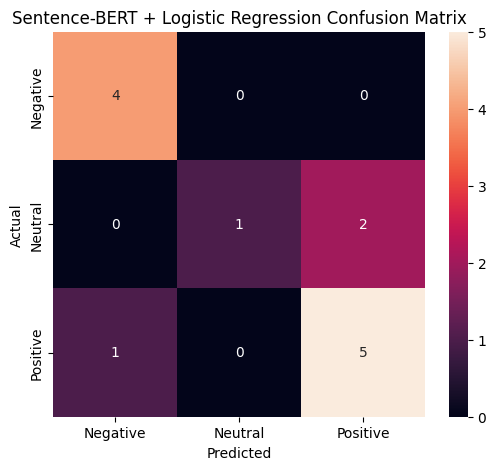

In [61]:
labels = [
    "Negative",
    "Neutral",
    "Positive"
]


cm = confusion_matrix(
    y_test_bert,
    bert_pred,
    labels=labels
)


plt.figure(
    figsize=(6,5)
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Sentence-BERT + Logistic Regression Confusion Matrix"
)

plt.show()

### SBERT + SVM


## Interpretasi Transformer-Based Sentiment Analysis

Sentence-BERT menghasilkan representasi teks berdasarkan konteks kalimat sehingga model dapat menangkap kemiripan makna meskipun menggunakan kata yang berbeda.

Pendekatan ini lebih sesuai untuk customer review karena pelanggan sering menyampaikan opini dengan variasi bahasa yang berbeda.

Namun, ukuran dataset yang kecil tetap menjadi pertimbangan dalam interpretasi performa model.


In [62]:
from sklearn.svm import LinearSVC


# Initialize model
bert_svm_model = LinearSVC(
    random_state=42
)


# Training
bert_svm_model.fit(
    X_train_bert,
    y_train_bert
)


# Prediction
bert_svm_pred = bert_svm_model.predict(
    X_test_bert
)

In [63]:
bert_svm_result = {
    "Model": "Sentence-BERT + Linear SVM",

    "Accuracy": accuracy_score(
        y_test_bert,
        bert_svm_pred
    ),

    "Precision": precision_score(
        y_test_bert,
        bert_svm_pred,
        average="weighted",
        zero_division=0
    ),

    "Recall": recall_score(
        y_test_bert,
        bert_svm_pred,
        average="weighted",
        zero_division=0
    ),

    "F1-Score": f1_score(
        y_test_bert,
        bert_svm_pred,
        average="weighted",
        zero_division=0
    )
}


pd.DataFrame(
    [bert_svm_result]
).round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Sentence-BERT + Linear SVM,0.7692,0.8066,0.7692,0.7439


# Analisis Topic Modeling

## 7. Topic Modeling Analysis




## Tujuan Topic Modeling

Setelah mengetahui polaritas sentimen pelanggan, tahap berikutnya adalah memahami alasan di balik opini tersebut.

Topic modeling digunakan untuk menemukan tema utama yang sering muncul dalam review tanpa membutuhkan label manual.

Dua pendekatan dibandingkan:
- LDA sebagai metode berbasis distribusi kata.
- BERTopic sebagai metode berbasis contextual embedding.


### 7.1 Text Preparation for Topic Modeling


In [64]:
import pandas as pd
import numpy as np
import re

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [65]:
stop_words = set(
    stopwords.words("english")
)

lemmatizer = WordNetLemmatizer()


def preprocess_topic(text):

    text = str(text)

    # lowercase
    text = text.lower()

    # remove HTML
    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    # remove URL
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    # remove punctuation
    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )

    # whitespace normalization
    text = " ".join(
        text.split()
    )

    # tokenization
    tokens = text.split()


    # stopword removal + lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]


    return tokens

In [67]:
df["topic_tokens"] = df["review_text"].apply(
    preprocess_topic
)

In [68]:
df[
    [
        "review_text",
        "topic_tokens"
    ]
].head()

,review_text,topic_tokens
0,These earbuds are incredible. Sound quality is...,"[earbuds, incredible, sound, quality, crisp, b..."
1,Finally got the whole ecosystem working. Setup...,"[finally, got, whole, ecosystem, working, setu..."
2,Wearing these for my morning runs and they're ...,"[wearing, morning, run, fantastic, comfy, star..."
3,This drill does everything I need and more. Po...,"[drill, everything, need, powerful, feel, good..."
4,"Wow, I've seen real results in just 3 weeks. M...","[wow, seen, real, result, week, skin, look, fi..."



## Interpretasi Text Preparation untuk Topic Modeling

Preprocessing topic modeling dibuat berbeda dari sentiment classification.

Tujuan utama preprocessing ini adalah mempertahankan kata yang memiliki informasi topik, bukan hanya meningkatkan performa klasifikasi.

Kata yang dipertahankan akan digunakan untuk menemukan pola tema yang muncul dalam kumpulan review.


### 7.2 LDA Topic Modeling


In [69]:
!pip install gensim

from gensim import corpora


dictionary = corpora.Dictionary(
    df["topic_tokens"]
)


corpus = [
    dictionary.doc2bow(text)
    for text in df["topic_tokens"]
]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 34.9 MB/s eta 0:00:00


In [70]:
from gensim import corpora


dictionary = corpora.Dictionary(
    df["topic_tokens"]
)


corpus = [
    dictionary.doc2bow(text)
    for text in df["topic_tokens"]
]

In [72]:
dictionary = corpora.Dictionary(
    df["topic_tokens"]
)


corpus = [
    dictionary.doc2bow(text)
    for text in df["topic_tokens"]
]

#Cek:

print(dictionary)
print(len(dictionary))


Dictionary<656 unique tokens: ['actually', 'bass', 'battery', 'cancellation', 'crisp']...>
656


In [73]:
from gensim.models import LdaModel


lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=3,
    random_state=42,
    passes=20,
    alpha="auto"
)

In [74]:
topics = lda_model.print_topics(
    num_words=8
)


for topic in topics:
    print(topic)


(0, '0.011*"work" + 0.011*"great" + 0.009*"fit" + 0.007*"overall" + 0.007*"good" + 0.007*"like" + 0.007*"weight" + 0.005*"nothing"')
(1, '0.012*"look" + 0.009*"quality" + 0.007*"durable" + 0.006*"one" + 0.006*"seems" + 0.006*"buy" + 0.006*"cheap" + 0.006*"love"')
(2, '0.010*"look" + 0.007*"worth" + 0.007*"work" + 0.007*"color" + 0.007*"day" + 0.007*"great" + 0.007*"perfectly" + 0.005*"way"')


In [75]:
from gensim.models import CoherenceModel


coherence_model = CoherenceModel(
    model=lda_model,
    texts=df["topic_tokens"],
    dictionary=dictionary,
    coherence="c_v"
)


coherence_score = coherence_model.get_coherence()


print(
    "Coherence Score:",
    coherence_score
)



Coherence Score: 0.47987747142225395


In [76]:
for k in range(2,6):

    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=20
    )

    coherence = CoherenceModel(
        model=lda,
        texts=df["topic_tokens"],
        dictionary=dictionary,
        coherence="c_v"
    ).get_coherence()

    print(
        k,
        coherence
    )


2 0.4144650806971403
3 0.46463677201319714
4 0.49133434133139675
5 0.4322831989257413



## Interpretasi Optimasi Jumlah Topic LDA

Jumlah topic diuji pada beberapa nilai untuk menemukan konfigurasi yang menghasilkan coherence score terbaik.

Coherence score digunakan untuk mengukur keterkaitan antar kata dalam sebuah topic.

Namun, pemilihan topic akhir tidak hanya berdasarkan nilai numerik, tetapi juga mempertimbangkan apakah topic tersebut mudah diinterpretasikan dan relevan secara bisnis.


### 7.3 BERTopic Modeling


In [78]:
!pip install bertopic sentence-transformers umap-learn hdbscan

from bertopic import BERTopic

from sentence_transformers import SentenceTransformer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.3 MB/s eta 0:00:00


In [79]:
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

documents = df["review_text"].tolist()

# Embedding:

embeddings = embedding_model.encode(
    documents,
    show_progress_bar=True
)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

In [80]:
from umap import UMAP


umap_model = UMAP(
    n_neighbors=5,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)


topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    min_topic_size=5
)

# Training:

topics, probabilities = topic_model.fit_transform(
    documents
)
# Melihat Topic BERTopic
topic_info = topic_model.get_topic_info()

topic_info


,Topic,Count,Name,Representation,Representative_Docs
0,0,52,0_the_and_it_is,"[the, and, it, is, but, my, to, for, of, on]",[Set up the tank and within 2 days fish were t...
1,1,12,1_and_fit_the_these,"[and, fit, the, these, for, it, colors, color,...",[Colors are gorgeous and blend beautifully. Bu...


In [81]:
# Melihat keyword:

for topic_id in topic_info.Topic:

    if topic_id != -1:
        print(
            topic_id,
            topic_model.get_topic(topic_id)
        )


0 [('the', np.float64(0.08907321710540127)), ('and', np.float64(0.07994248285994973)), ('it', np.float64(0.07517565974652432)), ('is', np.float64(0.07071892950041649)), ('but', np.float64(0.056327317340708595)), ('my', np.float64(0.05358971714124614)), ('to', np.float64(0.05219760878736142)), ('for', np.float64(0.04436796746925721)), ('of', np.float64(0.03679185621074722)), ('on', np.float64(0.03679185621074722))]
1 [('and', np.float64(0.11365806252141226)), ('fit', np.float64(0.09101677419580494)), ('the', np.float64(0.08634522639305459)), ('these', np.float64(0.07351498571026396)), ('for', np.float64(0.06679065978065728)), ('it', np.float64(0.06601463736528988)), ('colors', np.float64(0.06559444653244698)), ('color', np.float64(0.06559444653244698)), ('more', np.float64(0.06538593348429289)), ('are', np.float64(0.06307087900544092))]



## Interpretasi Topic BERTopic

BERTopic menggunakan sentence embedding untuk memahami hubungan semantik antar review.

Keyword yang dihasilkan merupakan representasi dari cluster review yang memiliki kemiripan makna.

Karena dataset terdiri dari berbagai kategori produk, beberapa topic dapat merepresentasikan kategori produk sekaligus pengalaman pelanggan.


### 7.4 Topic Comparison


In [82]:
# Membuat Ringkasan Topic LDA

lda_topics = []

for topic_id, topic in lda_model.show_topics(
    formatted=False
):

    keywords = [
        word
        for word, weight in topic
    ]

    lda_topics.append({
        "Method": "LDA",
        "Topic": topic_id,
        "Keywords": ", ".join(keywords)
    })


lda_topic_df = pd.DataFrame(
    lda_topics
)


lda_topic_df


,Method,Topic,Keywords
0,LDA,0,"work, great, fit, overall, good, like, weight,..."
1,LDA,1,"look, quality, durable, one, seems, buy, cheap..."
2,LDA,2,"look, worth, work, color, day, great, perfectl..."


In [83]:
# Ambil hasil BERTopic:

bertopic_topics = []


topic_info = topic_model.get_topic_info()


for topic_id in topic_info.Topic:

    if topic_id != -1:

        words = [
            word
            for word, score
            in topic_model.get_topic(topic_id)
        ]

        bertopic_topics.append({
            "Method": "BERTopic",
            "Topic": topic_id,
            "Keywords": ", ".join(words[:5])
        })


bertopic_topic_df = pd.DataFrame(
    bertopic_topics
)


bertopic_topic_df

,Method,Topic,Keywords
0,BERTopic,0,"the, and, it, is, but"
1,BERTopic,1,"and, fit, the, these, for"


In [84]:
# Gabungkan Hasil Topic


topic_comparison = pd.concat(
    [
        lda_topic_df,
        bertopic_topic_df
    ],
    ignore_index=True
)


topic_comparison


,Method,Topic,Keywords
0,LDA,0,"work, great, fit, overall, good, like, weight,..."
1,LDA,1,"look, quality, durable, one, seems, buy, cheap..."
2,LDA,2,"look, worth, work, color, day, great, perfectl..."
3,BERTopic,0,"the, and, it, is, but"
4,BERTopic,1,"and, fit, the, these, for"


In [93]:
# =====================================================
# FINAL TOPIC MODELING COMPARISON
# LDA vs BERTopic
# =====================================================


# -----------------------------
# Import Library
# -----------------------------

import re
import pandas as pd
import nltk

from nltk.tokenize import word_tokenize

from sentence_transformers import SentenceTransformer

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired

from umap import UMAP

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel



# Download NLTK resource

nltk.download("punkt")
nltk.download("punkt_tab")



# =====================================================
# 1. BERTopic Text Preparation
# =====================================================

def preprocess_bertopic(text):

    text = str(text).lower()


    # Remove URL
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )


    # Remove punctuation
    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )


    # Normalize whitespace
    text = " ".join(
        text.split()
    )


    return text



df["bertopic_text"] = df["review_text"].apply(
    preprocess_bertopic
)



documents = df["bertopic_text"].tolist()



# =====================================================
# 2. Sentence-BERT Embedding
# =====================================================

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)



embeddings = embedding_model.encode(
    documents,
    show_progress_bar=True
)



# =====================================================
# 3. UMAP Configuration
# =====================================================

umap_model = UMAP(
    n_neighbors=5,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)



# =====================================================
# 4. Build BERTopic Model
# =====================================================

representation_model = KeyBERTInspired()



topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    min_topic_size=5,
    representation_model=representation_model
)



topics, probabilities = topic_model.fit_transform(
    documents,
    embeddings
)



# =====================================================
# 5. BERTopic Information
# =====================================================

topic_info = topic_model.get_topic_info()



print("===== BERTopic Topic Information =====")

display(topic_info)



# =====================================================
# 6. Extract BERTopic Keywords
# =====================================================

bert_topic_words = []


for topic_id in topic_info["Topic"]:

    if topic_id != -1:

        words = [
            word
            for word, score
            in topic_model.get_topic(topic_id)
        ]

        bert_topic_words.append(
            words
        )



print(
    "Number of BERTopic:",
    len(bert_topic_words)
)



# =====================================================
# 7. BERTopic Coherence Calculation
# =====================================================

if len(bert_topic_words) >= 2:


    bert_tokens = [
        word_tokenize(text)
        for text in documents
    ]


    bert_dictionary = Dictionary(
        bert_tokens
    )


    bert_coherence_model = CoherenceModel(
        topics=bert_topic_words,
        texts=bert_tokens,
        dictionary=bert_dictionary,
        coherence="c_v"
    )


    bert_coherence = (
        bert_coherence_model
        .get_coherence()
    )


else:

    bert_coherence = None



# =====================================================
# 8. LDA vs BERTopic Comparison
# =====================================================

topic_comparison = pd.DataFrame({

    "Method":[
        "LDA",
        "BERTopic"
    ],

    "Representation":[
        "Word Distribution",
        "Sentence Embedding"
    ],

    "Coherence Score":[
        coherence_score,
        bert_coherence
    ]

})



print("\n===== Topic Modeling Comparison =====")

display(
    topic_comparison.round(4)
)



# =====================================================
# 9. Topic Keywords Summary
# =====================================================

print("\n===== LDA Topics =====")


for topic_id, topic in lda_model.show_topics(
    formatted=False
):

    words = [
        word
        for word, weight in topic
    ]

    print(
        f"Topic {topic_id}:",
        ", ".join(words)
    )



print("\n===== BERTopic Topics =====")


for topic_id in topic_info["Topic"]:

    if topic_id != -1:

        print(
            f"\nTopic {topic_id}:"
        )

        print(
            topic_model.get_topic(topic_id)
        )

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

===== BERTopic Topic Information =====


,Topic,Count,Name,Representation,Representative_Docs
0,-1,8,-1_recommend_appreciate_useful_abs,"[recommend, appreciate, useful, abs, enjoyed, ...",[my dog got sick from these treats don t know ...
1,0,18,0_durable_quality_extraordinary_fragile,"[durable, quality, extraordinary, fragile, cri...",[sound quality is decent noise cancellation wo...
2,1,16,1_customer_durable_claim_quality,"[customer, durable, claim, quality, damage, el...",[looks nice and matches my bedroom drawers sli...
3,2,15,2_sizing_fit_refund_workouts,"[sizing, fit, refund, workouts, shoes, fits, b...",[jacket fell apart after wears seams are comin...
4,3,7,3_blender_garbage_softer_kind,"[blender, garbage, softer, kind, absorbs, look...",[hair feels softer and looks shinier after usi...


Number of BERTopic: 4

===== Topic Modeling Comparison =====


,Method,Representation,Coherence Score
0,LDA,Word Distribution,0.4799
1,BERTopic,Sentence Embedding,0.4725



===== LDA Topics =====
Topic 0: work, great, fit, overall, good, like, weight, nothing, really, water
Topic 1: look, quality, durable, one, seems, buy, cheap, love, good, absolutely
Topic 2: look, worth, work, color, day, great, perfectly, way, skin, fit

===== BERTopic Topics =====

Topic 0:
[('durable', np.float32(0.27740008)), ('quality', np.float32(0.23669678)), ('extraordinary', np.float32(0.22290625)), ('fragile', np.float32(0.1960706)), ('crispy', np.float32(0.18450966)), ('bathroom', np.float32(0.1783446)), ('design', np.float32(0.16260937)), ('keyboard', np.float32(0.16217206)), ('evenly', np.float32(0.15874887)), ('flaw', np.float32(0.15639833))]

Topic 1:
[('customer', np.float32(0.34241474)), ('durable', np.float32(0.28991246)), ('claim', np.float32(0.2739513)), ('quality', np.float32(0.2671511)), ('damage', np.float32(0.21689388)), ('electronics', np.float32(0.21462037)), ('cheaply', np.float32(0.21211374)), ('depth', np.float32(0.19433974)), ('made', np.float32(0.1907391


## Interpretasi Perbandingan LDA dan BERTopic

Hasil evaluasi menunjukkan bahwa kedua metode mampu menemukan pola tema dalam review pelanggan.

LDA menghasilkan topic berbasis hubungan kemunculan kata, sedangkan BERTopic menghasilkan topic berdasarkan kemiripan makna melalui embedding.

Dengan dataset kecil dan heterogen, evaluasi akhir tidak hanya menggunakan coherence score, tetapi juga mempertimbangkan:
- interpretasi topic,
- kualitas keyword,
- relevansi terhadap insight bisnis.

BERTopic memberikan topic yang lebih mudah diterjemahkan menjadi kebutuhan bisnis karena mempertimbangkan konteks kalimat.


### 7.5 Business Interpretation


# Business Interpretation

Berdasarkan hasil topic modeling, beberapa pola utama pelanggan dapat dirangkum:

### 1. Product Quality and Durability
Pelanggan banyak mengevaluasi kualitas material, ketahanan produk, dan kemungkinan kerusakan.

**Implikasi bisnis:**
Perusahaan dapat meningkatkan quality control dan memantau pola kerusakan produk.

### 2. Product Fit and Expectation Gap
Beberapa keluhan berkaitan dengan ukuran, kecocokan, dan kebutuhan refund.

**Implikasi bisnis:**
Informasi produk dan sistem rekomendasi dapat diperbaiki untuk mengurangi ketidaksesuaian ekspektasi.

### 3. Product Category Variation
Dataset mencakup berbagai kategori produk sehingga pola keluhan dapat berbeda antar kategori.

**Implikasi bisnis:**
Analisis lanjutan sebaiknya mempertimbangkan segmentasi berdasarkan kategori produk.
